In [2]:
from typing import Annotated,TypedDict
from operator import add
from langgraph.graph import StateGraph,START,END

# 1. 定义状态
class OverAllState(TypedDict):
    """
    定义图运行过程中需要共享的状态
    """
    # 日志类型是list[str]，更新的方式不是覆盖，是追加
    logs: Annotated[list[str], add]
    # 当前的id
    cur_id: str

# 2. 定义节点
def node_1(state: OverAllState) -> OverAllState:
    """
    节点1：生成日志
    """
    # 初始调用可能未传 cur_id，用 get 给默认值，避免 KeyError
    pre_id = state.get("cur_id", "start")
    return {
        "logs": ["node_1运行完毕"],
        "cur_id": pre_id + ",node_1",
    }


def node_2(state: OverAllState) -> OverAllState:
    """
    节点2：生成日志
    """
    pre_id = state.get("cur_id", "start")
    return {
        "logs": ["node_2运行完毕"],
        "cur_id": pre_id + ",node_2",
    }


# 3. 定义边
# 3.1 创建图 获取建造者
builder = StateGraph(state_schema=OverAllState)
# 3.2 添加节点
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
# 3.3 添加边
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)
# 3.4 获取图
graph = builder.compile()

# 3.5 运行图：初始状态建议同时提供 logs 和 cur_id
print(graph.invoke({"logs": ["开始运行"], "cur_id": "start"}))
print(graph.invoke({"logs": ["开始运行222"], "cur_id": "start"}))



{'logs': ['开始运行', 'node_1运行完毕', 'node_2运行完毕'], 'cur_id': 'start,node_1,node_2'}
{'logs': ['开始运行222', 'node_1运行完毕', 'node_2运行完毕'], 'cur_id': 'start,node_1,node_2'}


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



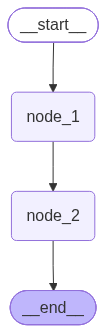

In [3]:
from IPython.display import Image, display, Markdown

# 1) 拿到 Mermaid 文本（可复制到 https://mermaid.live 预览）
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

# 2) 在 Notebook 中直接渲染成 PNG 图（推荐）
display(Image(graph.get_graph().draw_mermaid_png()))

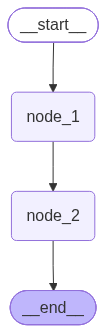

In [4]:
# 直接展示图片
from IPython.display import display, Image

png_bytes = graph.get_graph().draw_mermaid_png()
png = Image(png_bytes)
display(png)

## 图的状态管理
### TypeDict定义状态

In [ ]:
# TypeDict定义状态
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from operator import add

# 通过typeDict定义状态
class OverAllState(TypedDict):
    logs: Annotated[list[str], add]
    cur_id: str

### dataclass定义状态
属性调用方式由['字段名']改为.字段名

In [5]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from dataclasses import dataclass
from operator import add

@dataclass
class OverAllState:
    logs: Annotated[list[str], add]
    cur_id: str

def node_1(state: OverAllState) -> OverAllState:
    pre_id = state.cur_id
    return {
        "logs": ["node_1 运行完毕"],
        "cur_id": pre_id + ", node_1"
    }

def node_2(state: OverAllState) -> OverAllState:
    pre_id = state.cur_id
    return {
        "logs": ["node_2 运行完毕"],
        "cur_id": pre_id + ", node_2"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()

print(graph.invoke({"cur_id": "start"}))

{'logs': ['node_1 运行完毕', 'node_2 运行完毕'], 'cur_id': 'start, node_1, node_2'}


### Pydantic定义状态
Pydantic模型的字段访问方式和dataclass相同。

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from pydantic import BaseModel
from operator import add

class OverAllState(BaseModel):
    logs: Annotated[list[str], add]
    cur_id: str

def node_1(state: OverAllState) -> OverAllState:
    pre_id = state.cur_id
    return {
        "logs": ["node_1 运行完毕"],
        "cur_id": pre_id + ", node_1"
    }

def node_2(state: OverAllState) -> OverAllState:
    pre_id = state.cur_id
    return {
        "logs": ["node_2 运行完毕"],
        "cur_id": pre_id + ", node_2"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()

print(graph.invoke({"cur_id": "start"}))

{'logs': ['node_1 运行完毕', 'node_2 运行完毕'], 'cur_id': 'start, node_1, node_2'}


In [7]:
# 定义reducer函数
def my_reducer(left: list[str], right: list[str]) -> list[str]:
    return left + right

left = ['a', 'b']
right = ['c']
print(my_reducer(left, right))
"""
left: 当前已累计的状态值
right: 本次代合并的新值
"""

['a', 'b', 'c']
